In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv('goog.csv')

# Display first rows
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [3]:
# Use only 'Close' price for prediction
data = df['Close'].values.reshape(-1,1)

In [4]:
from sklearn.preprocessing import MinMaxScaler
# Scale values between 0 and 1
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [5]:
# Train-Test Split
train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

In [6]:
# Create time series sequences
def create_dataset(data, step=4):
    X, y = [], []
    for i in range(len(data)-step):
        X.append(data[i:i+step])
        y.append(data[i+step])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train)
X_test, y_test = create_dataset(test)

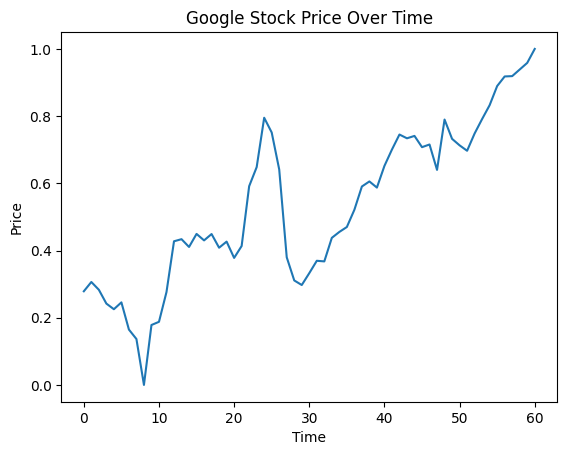

In [7]:
plt.plot(data)
plt.title("Google Stock Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [8]:
print("Total rows:", len(df))
print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Total rows: 61
Train samples: 44
Test samples: 9


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
# Build Simple RNN model
model_rnn = Sequential()

model_rnn.add(SimpleRNN(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_rnn.add(SimpleRNN(50))
model_rnn.add(Dense(1))

model_rnn.compile(optimizer='adam', loss='mean_squared_error')

# Train RNN
history_rnn = model_rnn.fit(X_train, y_train, epochs=30)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.6614
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0707
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1301
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2167
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1378
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0451
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0306
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0564
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0764
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0672
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0417
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0263
Epoch 13/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0255
Epoch 14/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0306
Epoch 15/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0321
Epoch 16/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/

In [10]:
# Predict using RNN
y_pred_rnn = model_rnn.predict(X_test)

# Convert back to original values
y_pred_rnn = scaler.inverse_transform(y_pred_rnn)
y_test_inv = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step


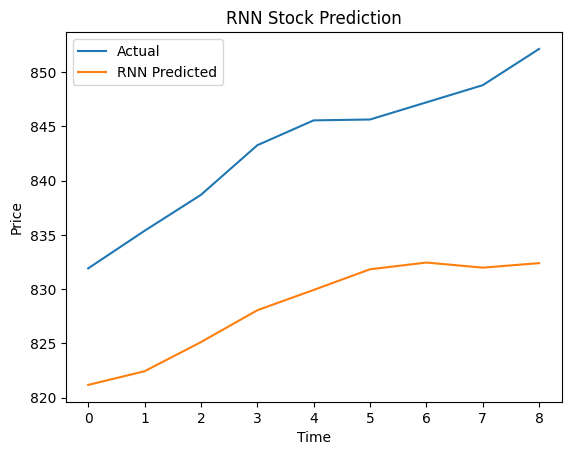

In [11]:
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_rnn, label='RNN Predicted')

plt.title("RNN Stock Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [12]:
# Build LSTM model
model_lstm = Sequential()

model_lstm.add(LSTM(50, return_sequences=True,input_shape=(X_train.shape[1], 1)))
model_lstm.add(LSTM(50))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Train LSTM
history_lstm = model_lstm.fit(X_train, y_train, epochs=50)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.2547
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2223
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1939
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1660
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1396
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1134
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0881
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0646
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0431
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0287
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0226
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0235
Epoch 13/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0302
Epoch 14/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0332
Epoch 15/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0307
Epoch 16/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/

In [13]:
# Predict using LSTM
y_pred_lstm = model_lstm.predict(X_test)

# Convert back to original values
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


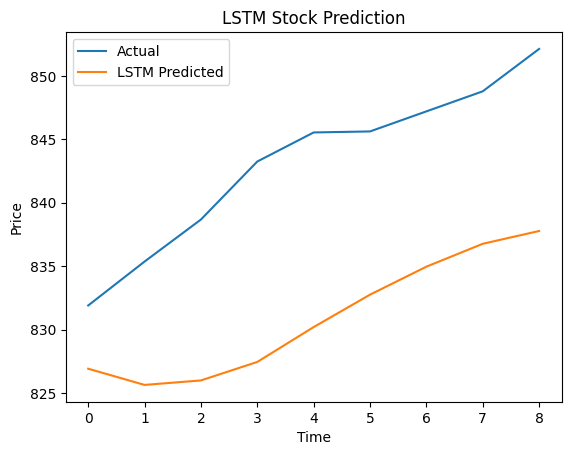

In [14]:


plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_lstm, label='LSTM Predicted')

plt.title("LSTM Stock Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

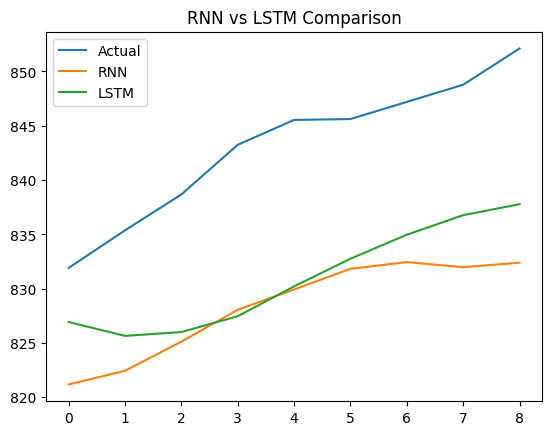

In [15]:
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_rnn, label='RNN')
plt.plot(y_pred_lstm, label='LSTM')

plt.title("RNN vs LSTM Comparison")
plt.legend()
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error

rmse_rnn = np.sqrt(mean_squared_error(y_test_inv, y_pred_rnn))
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_lstm))

print("RNN RMSE:", rmse_rnn)
print("LSTM RMSE:", rmse_lstm)

RNN RMSE: 14.98344347706218
LSTM RMSE: 12.601484465683166
